In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df = pd.read_csv("../../data/final_dataset.csv")
sns.set_theme(style="whitegrid")



/tmp/ipykernel_534906/178338333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=class_order, palette='viridis')


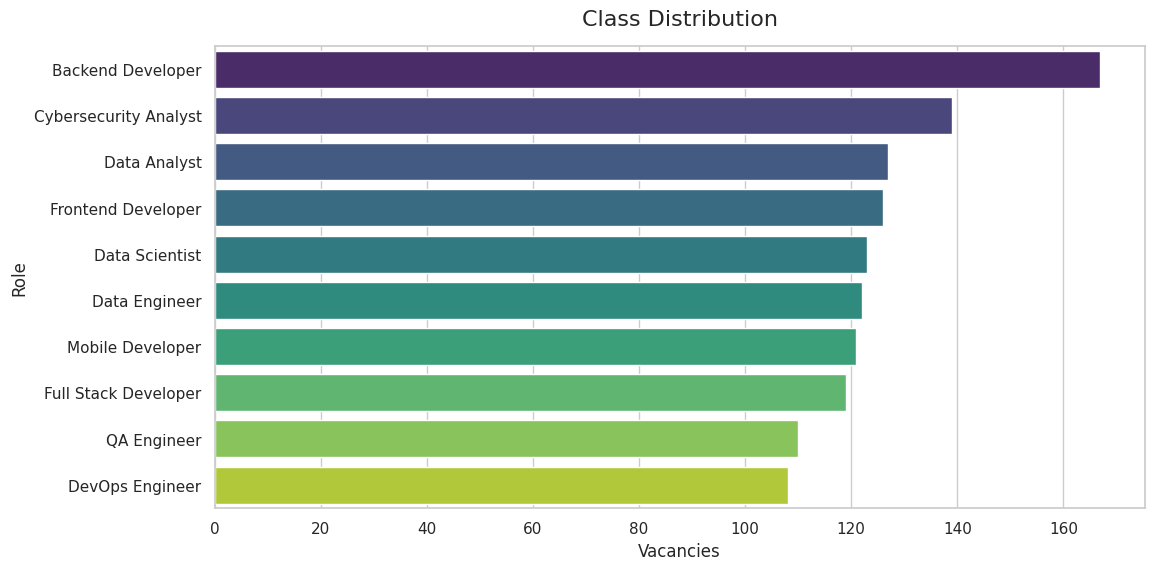

In [14]:
plt.figure(figsize=(12, 6))
class_order = df['label'].value_counts().index
sns.countplot(data=df, y='label', order=class_order, palette='viridis')

plt.title('Class Distribution', fontsize=16, pad=15)
plt.xlabel('Vacancies', fontsize=12)
plt.ylabel('Role', fontsize=12)

plt.savefig('../../outputs/class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

/tmp/ipykernel_534906/2560388723.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_skills, x='skill_count', y='label', palette='mako')


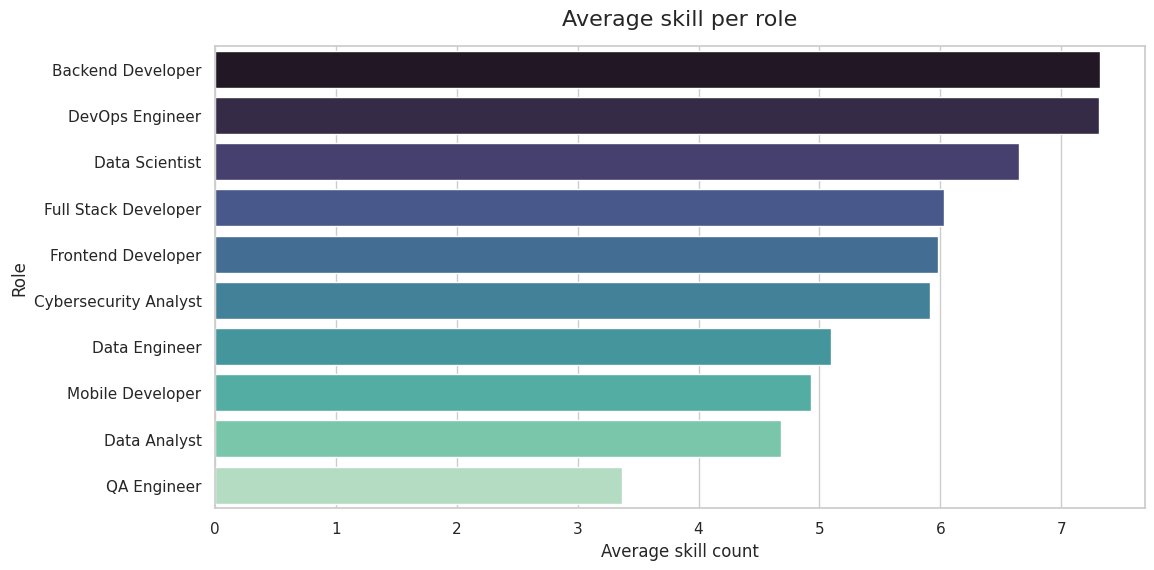

In [15]:
df['skill_count'] = df['skills'].fillna('').apply(lambda x: len(str(x).split(', ')) if x else 0)

plt.figure(figsize=(12, 6))

avg_skills = df.groupby('label')['skill_count'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=avg_skills, x='skill_count', y='label', palette='mako')

plt.title('Average skill per role', fontsize=16, pad=15)
plt.xlabel('Average skill count', fontsize=12)
plt.ylabel('Role', fontsize=12)

plt.savefig('../../outputs/average_skills_per_role.png', bbox_inches='tight', dpi=150)
plt.show()

<Figure size 1000x600 with 0 Axes>

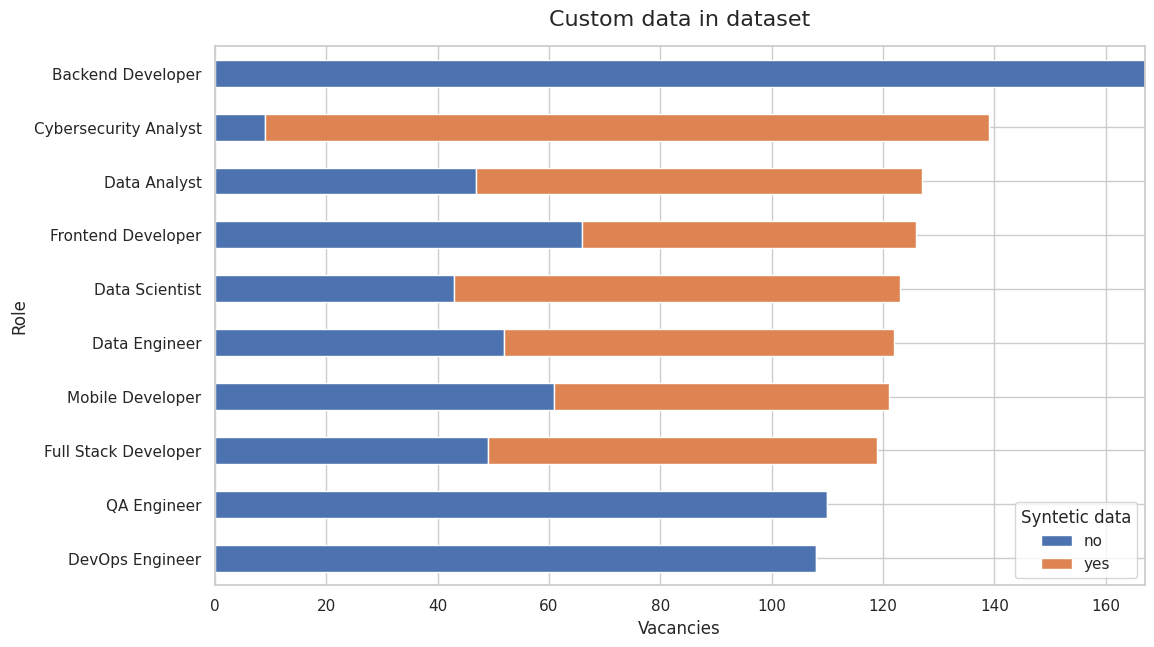

In [16]:
plt.figure(figsize=(10, 6))

custom_dist = pd.crosstab(df['label'], df['is_custom'])

custom_dist['total'] = custom_dist.sum(axis=1)
custom_dist = custom_dist.sort_values('total', ascending=True).drop('total', axis=1)

custom_dist.plot(kind='barh', stacked=True, figsize=(12, 7), color=['#4C72B0', '#DD8452'])

plt.title('Custom data in dataset', fontsize=16, pad=15)
plt.xlabel('Vacancies', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.legend(title='Syntetic data')

plt.savefig('../../outputs/custom_vs_public.png', bbox_inches='tight', dpi=150)
plt.show()

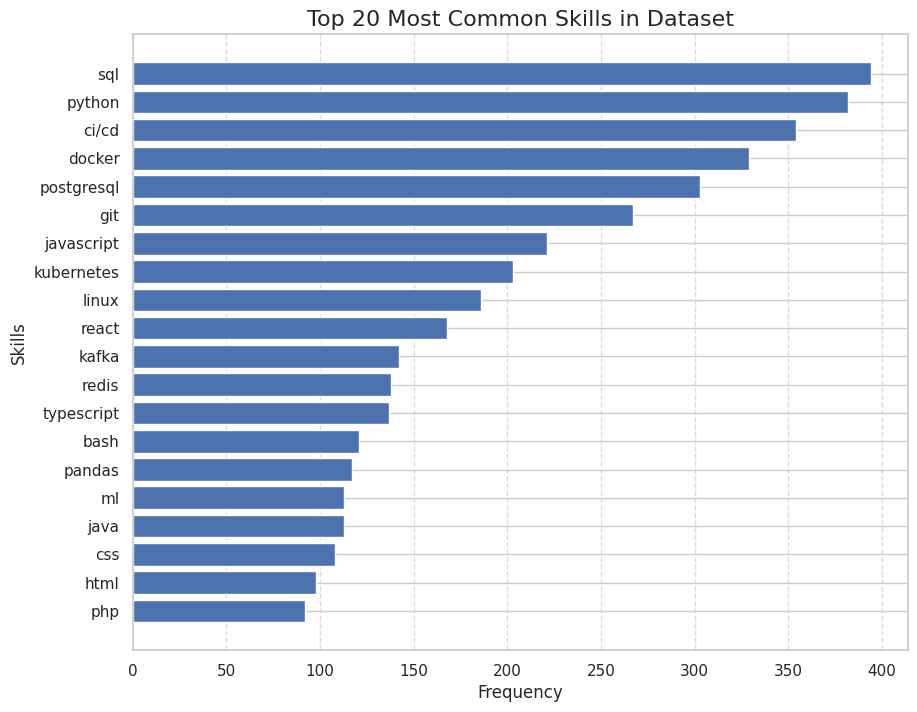

In [17]:
all_skills = []
for skills_row in df['skills']:
    all_skills.extend(skills_row.split(", "))

skills_counts = Counter(all_skills)

top_20_skills = skills_counts.most_common(20)

skills_names = [item[0] for item in top_20_skills]
skills_values = [item[1] for item in top_20_skills]

skills_names.reverse()
skills_values.reverse()

plt.figure(figsize=(10, 8))
plt.barh(skills_names, skills_values, color='#4C72B0') 

plt.title('Top 20 Most Common Skills in Dataset', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Skills', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.savefig('../../outputs/top_20_skills.png', bbox_inches='tight', dpi=150)
plt.show()


<Figure size 1000x600 with 0 Axes>

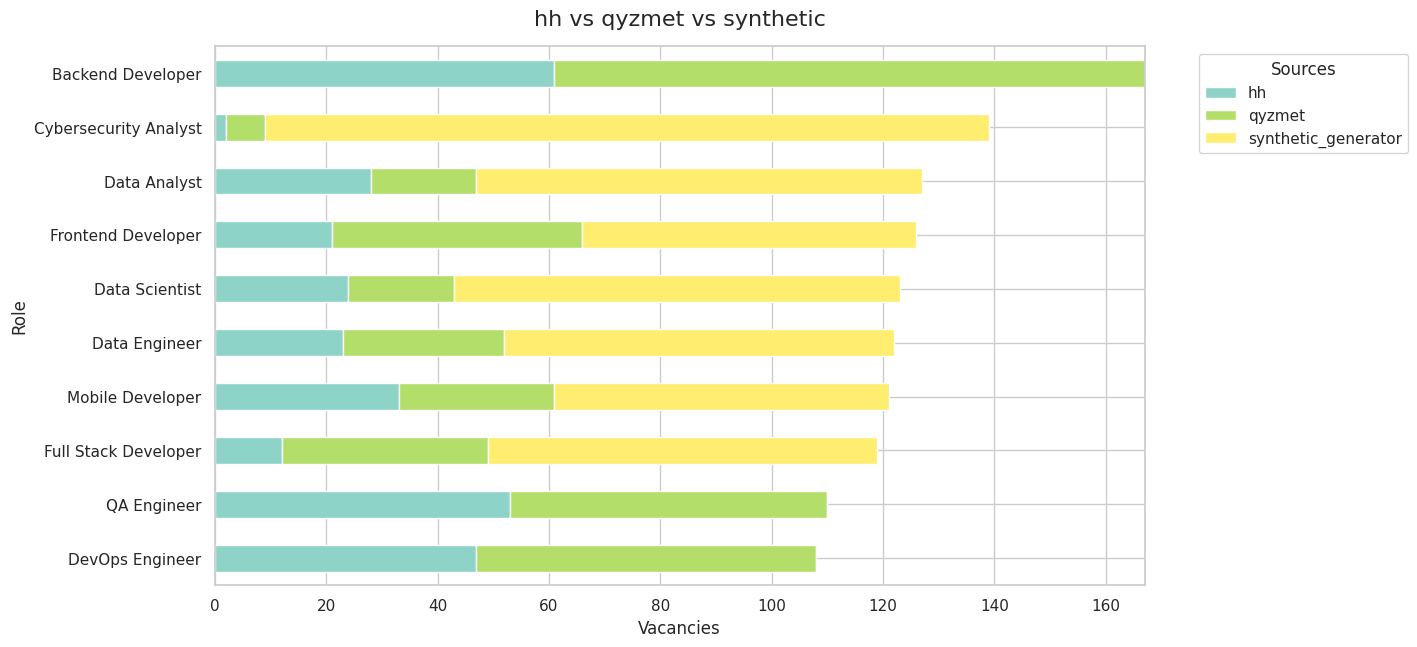

In [24]:
plt.figure(figsize=(10, 6))

custom_dist = pd.crosstab(df['label'], df['source'])

custom_dist['total'] = custom_dist.sum(axis=1)
custom_dist = custom_dist.sort_values('total', ascending=True).drop('total', axis=1)

custom_dist.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='Set3', edgecolor='white')

plt.title('hh vs qyzmet vs synthetic', fontsize=16, pad=15)
plt.xlabel('Vacancies', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.legend(title='Sources', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('../../outputs/hh_vs_qyzmet.png', bbox_inches='tight', dpi=150)
plt.show()

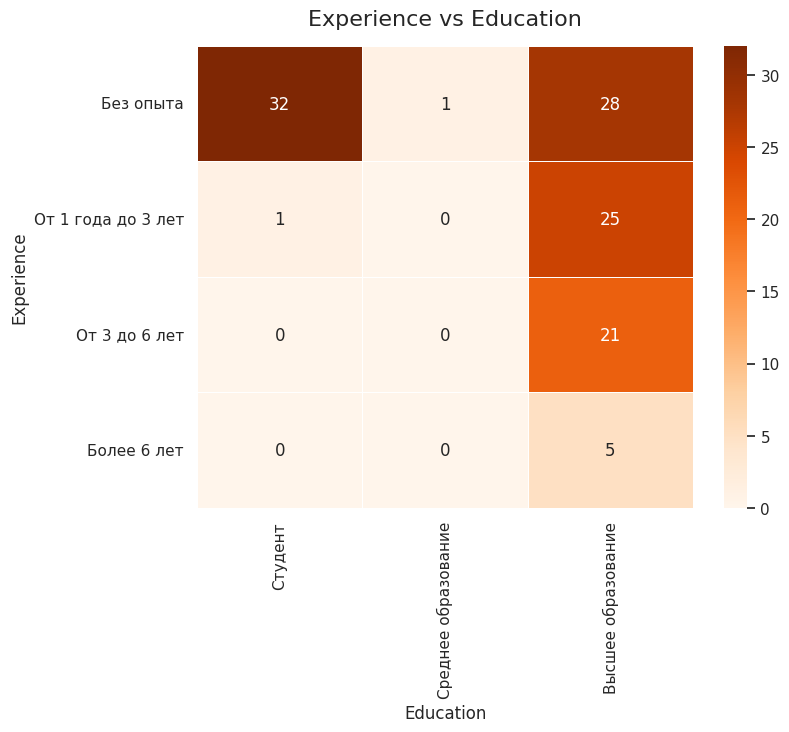

In [33]:
df_exploded = df.copy()
df_exploded['skill'] = df_exploded['skills'].apply(lambda x: str(x).split(', '))

df_exploded = df_exploded.explode('skill')

top_15_skills = df_exploded['skill'].value_counts().head(15).index.tolist()
df_top = df_exploded[df_exploded['skill'].isin(top_15_skills)]

exp_order = ['Без опыта', 'От 1 года до 3 лет', 'От 3 до 6 лет', 'Более 6 лет']
edu_order = ['Студент', 'Среднее образование', 'Высшее образование']


exp_edu_cross = pd.crosstab(df['experience_level'], df['education_level'])
exp_edu_cross = exp_edu_cross.reindex(
    index=[idx for idx in exp_order if idx in exp_edu_cross.index],
    columns=[col for col in edu_order if col in exp_edu_cross.columns]
)

plt.figure(figsize=(8, 6))
sns.heatmap(exp_edu_cross, annot=True, cmap='Oranges', fmt="d", linewidths=.5)

plt.title('Experience vs Education', fontsize=16, pad=15)
plt.ylabel('Experience', fontsize=12)
plt.xlabel('Education', fontsize=12)

plt.savefig('../../outputs/heatmap_experience_vs_education.png', bbox_inches='tight', dpi=150)
plt.show()